## EDA (Exploratory Data Analysis)

In [10]:
## Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
## Load Dataset
df = pd.read_csv("../data/processed/Cleaned-Telco-Customer-Churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Contract, Billing & Pricing Analysis

### 1. Which contract type has the highest churn?

In [12]:
contract_type_wise_churn = (df.groupby(['Contract'])['Churn'].value_counts(normalize=True)*100).round(2).reset_index()

contract_type_wise_churned = contract_type_wise_churn[contract_type_wise_churn["Churn"] == 'Yes']

contract_type_wise_churned

,Contract,Churn,proportion
1,Month-to-month,Yes,42.68
3,One year,Yes,11.32
5,Two year,Yes,2.85


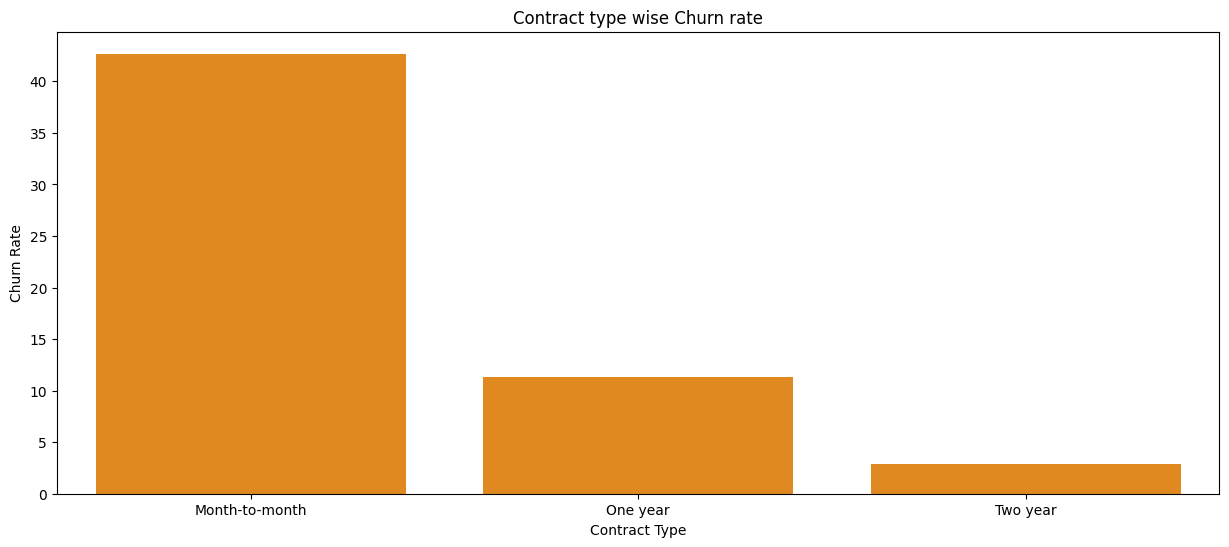

In [13]:
plt.figure(figsize=(15,6))
sns.barplot(data=contract_type_wise_churned, x='Contract', y='proportion', color='darkorange')
plt.title("Contract type wise Churn rate")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate");

#### Comments:
The **month-to-month** contract type has the highest churn rate of *42.68%*, indicating that customers with this contract type are more likely to leave the service compared to those with one-year or two-year contracts.

### 2. Does monthly billing increase churn compared to long-term contracts?

Yes, monthly billing is associated with a higher churn rate compared to long-term contracts. Customers on month-to-month plans exhibit a significantly higher churn rate, suggesting that the flexibility of monthly billing may lead to increased customer turnover.

### 3. How does churn vary by payment method?

In [14]:
payment_method_wise_churn = (df.groupby(['PaymentMethod'])['Churn'].value_counts(normalize=True)*100).round(2).reset_index()

payment_method_wise_churned = payment_method_wise_churn[payment_method_wise_churn["Churn"] == 'Yes'].sort_values(by='proportion', ascending=False)

payment_method_wise_churned

,PaymentMethod,Churn,proportion
5,Electronic check,Yes,45.28
7,Mailed check,Yes,19.23
1,Bank transfer (automatic),Yes,16.73
3,Credit card (automatic),Yes,15.24


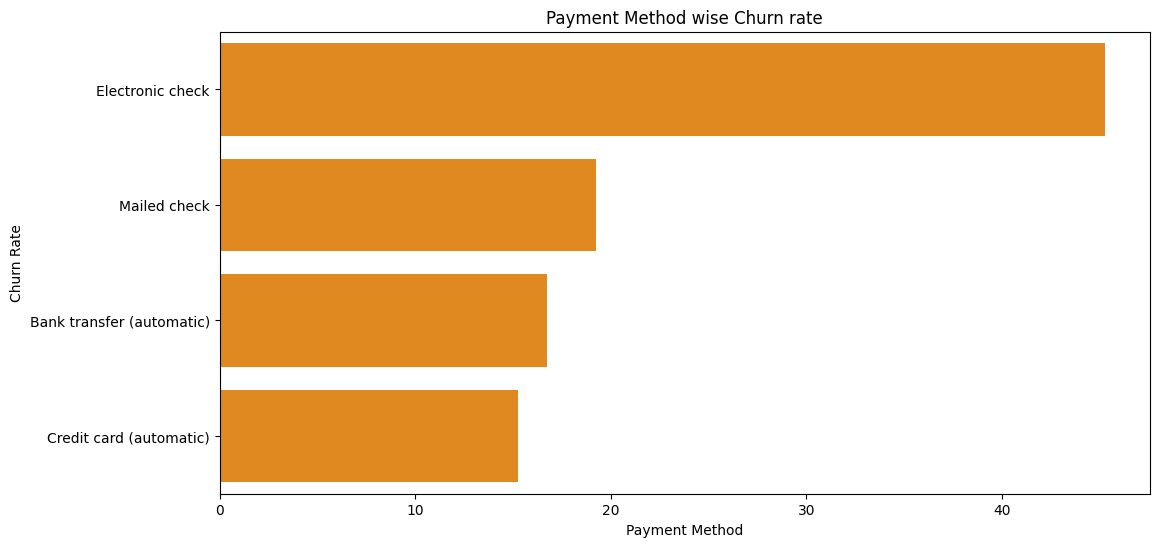

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(data=payment_method_wise_churned, y='PaymentMethod', x='proportion', color='darkorange', orient='h')
plt.title("Payment Method wise Churn rate")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate");

### Comments:
Churn rates differ across payment methods, with **electronic check** payments showing the *highest* churn rate (approxmately 45.28%). 

This suggests that customers using electronic checks may be less committed to the service compared to those using other payment methods like credit cards or bank transfers.

### 4. Do customers using electronic checks churn more?

**Yes**, customers who use electronic checks as their payment method tend to have a higher churn rate compared to those using other payment methods.

### 5. Is higher monthly charge associated with higher churn?

In [16]:
percentile = df['MonthlyCharges'].quantile([x/100 for x in range(0, 101, 5)]).values
percentile

array([ 18.25,  19.65,  20.05,  20.6 ,  25.05,  35.55,  45.85,  53.15,
        58.85,  65.5 ,  70.35,  74.75,  79.1 ,  81.45,  85.5 ,  89.85,
        94.25,  98.5 , 102.6 , 107.4 , 118.75])

In [17]:
monthly_charge_churn = df[['MonthlyCharges', 'Churn']]
monthly_charge_churn

,MonthlyCharges,Churn
0,29.85,No
1,56.95,No
2,53.85,Yes
3,42.30,No
4,70.70,Yes
...,...,...
7016,21.15,No
7017,84.80,No
7018,29.60,No
7019,74.40,Yes


In [18]:

for x in range(len(percentile)-1):
    mask = (df['MonthlyCharges'] >= percentile[x]) & (df['MonthlyCharges'] <= percentile[x+1])
    avg_price = df[mask]['MonthlyCharges'].mean()
    # monthly_charge_churn['MonthlyCharges'] = monthly_charge_churn['MonthlyCharges'].apply(lambda i: avg_price if (i >= percentile[x]) & (i<= percentile[x+1]) else i)
    monthly_charge_churn.loc[:, 'MonthlyCharges'] = (
        monthly_charge_churn['MonthlyCharges']
        .apply(lambda i: avg_price if (i >= percentile[x]) & (i <= percentile[x+1]) else i)
    )





In [19]:
monthly_charge_churn

,MonthlyCharges,Churn
0,28.458848,No
1,55.387394,No
2,55.387394,Yes
3,42.665483,No
4,72.765642,Yes
...,...,...
7016,23.173442,No
7017,84.103090,No
7018,28.458848,No
7019,72.765642,Yes


In [20]:
churn_trend_with_monthly_charge = monthly_charge_churn.groupby(['MonthlyCharges'])['Churn'].agg([lambda x: (x=='Yes').mean().round(2), 'count']).reset_index()

churn_trend_with_monthly_charge.columns = ['Monthly_Charges_Bin_Avg', 'Churn_Rate', 'Customer_Count']

churn_trend_with_monthly_charge

,Monthly_Charges_Bin_Avg,Churn_Rate,Customer_Count
0,19.375000,0.09,360
1,19.861083,0.08,354
2,20.281250,0.10,347
3,23.173442,0.10,354
4,28.458848,0.20,342
5,42.665483,0.31,350
6,49.663165,0.28,351
7,55.387394,0.21,351
8,61.944522,0.12,354
9,68.773669,0.32,352


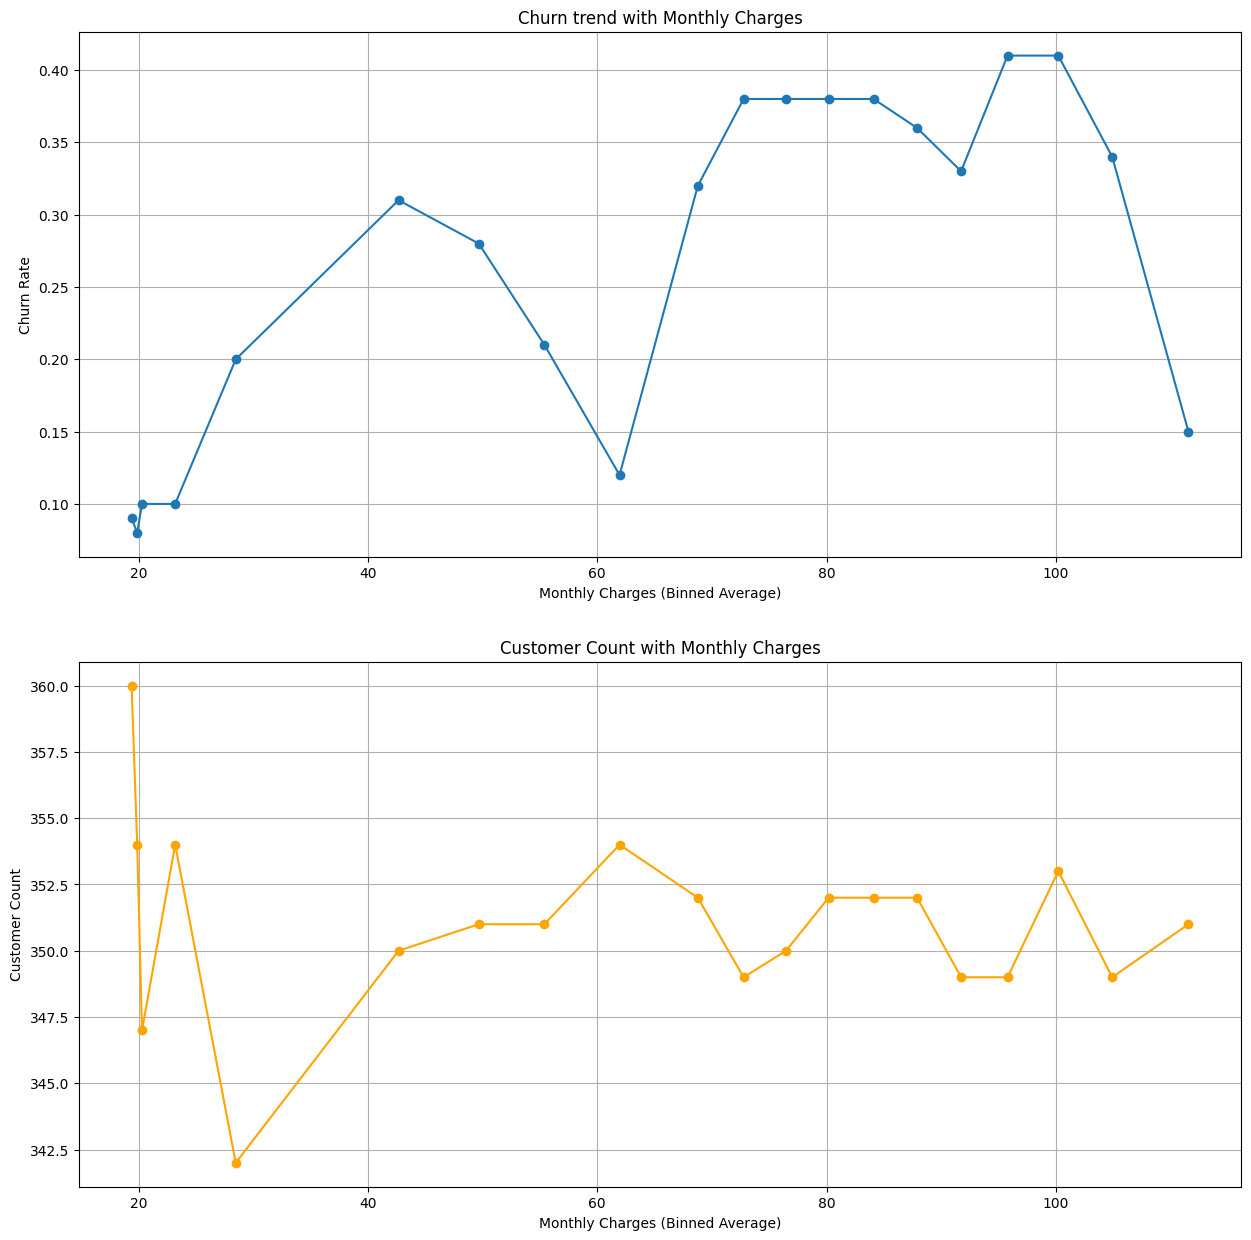

In [21]:
## Visualization of churn trend with MonthlyCharges
plt.figure(figsize=(15,15))
plt.subplot(2,1,1)
plt.plot(churn_trend_with_monthly_charge['Monthly_Charges_Bin_Avg'], churn_trend_with_monthly_charge['Churn_Rate'], marker='o')
plt.title("Churn trend with Monthly Charges")
plt.xlabel("Monthly Charges (Binned Average)")
plt.ylabel("Churn Rate")
plt.grid()

plt.subplot(2,1,2)
plt.plot(churn_trend_with_monthly_charge['Monthly_Charges_Bin_Avg'], churn_trend_with_monthly_charge['Customer_Count'], marker='o', color='orange')
plt.title("Customer Count with Monthly Charges")
plt.xlabel("Monthly Charges (Binned Average)")
plt.ylabel("Customer Count")
plt.grid()
plt.show()

#### Comments:
* The analysis indicates a clear trend of churn rates with monthly charges. 
* Customers with lower monthly charges (around $18.25 to $23.28) exhibit a churn rate of approximately *10%*.
* As monthly charges increase, the churn rate also rises, reaching up to *40%* for customers with monthly charges in the range of approximately $89.55 to $100.
* Again, churn rates around monthly charges $ 110 is very less approximately *15%*. May be because of others factors.
* However, the no of customers in all groups remains same around 350 customers.

### 6. How does churn differ across billing paperless vs non-paperless customers?

In [22]:
paperlessBilling_wise_churn_rate = df.groupby(['PaperlessBilling'])['Churn'].agg([lambda x: (x=='Yes').mean().round(2), 'count']).reset_index()

paperlessBilling_wise_churn_rate.columns = ['PaperlessBilling', 'churn_rate', 'customers']

paperlessBilling_wise_churn_rate

,PaperlessBilling,churn_rate,customers
0,No,0.16,2862
1,Yes,0.34,4159


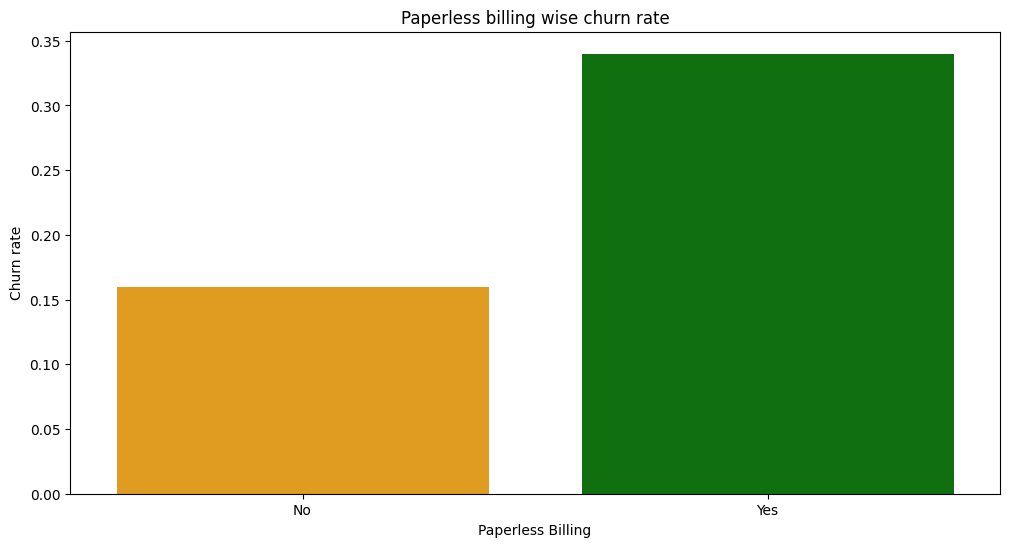

In [23]:
plt.figure(figsize=(12, 6))

sns.barplot(data=paperlessBilling_wise_churn_rate, x='PaperlessBilling', y='churn_rate', hue='PaperlessBilling', legend=False, palette=['orange', 'green'])
plt.title('Paperless billing wise churn rate')
plt.xlabel('Paperless Billing')
plt.ylabel('Churn rate');

#### Comment:
This analysis reveals that customers who opt for *paperless billing* exhibit a significantly higher churn rate of approximately *33.59%* compared to those who do not use paperless billing, who have a churn rate of about *16.39%*.

Though no of customers using paperless billing is higher (about 4159) compared to non-paperless which is 2862. This suggests that while paperless billing may offer convenience, it is also associated with a greater likelihood of customer attrition.

#### Conclusions :
1. Customers with contract type **month-to-month** has the highest churn rate almost 42.68%.
2. Customers who uses **electronic check** for their payment has significantly higher churn rate and that is 42.28%.
3. If monthly charges is low (around **$18.25** to **$23.28**) churn rate is also low **10%**, with the increase of monthly charges (**$89.55** to **$100**) churn rate also increases (**40%**) and finally at higher monthly charges (**$110**) churn rate becomes low again (almost **15%**).

---
### Author Information
**Name:** [Apabrita Maity]  
**Date:** 2026-01-07  
**Role:** [Data Analyst | Data Scientist]

### Let's Connect!
If you have questions about this analysis or would like to collaborate, feel free to reach out:

*  **LinkedIn:** [LinkedIn](https://www.linkedin.com/in/apabritamaity/)
*  **GitHub:** [@apabritamaity](https://github.com/apabritamaity/data-analyst-portfolio)
*  **Email:** [contacttoapabrita@gmail.com](mailto:contacttoapabrita@gmail.com)